# **Project 2: House Price Prediction (Complete End-to-End Machine Learning Project)**

This project demonstrates a full machine learning workflow: data processing → feature engineering → model training → evaluation → deployment.

Dataset platform: Kaggle
Coding environment: Jupyter Notebook
Deployment: Streamlit
ML library: Scikit-learn

# **Project Goal**

Build a machine learning model that predicts house prices based on property features.

**Example features:**

house size

number of bedrooms

location

year built

bathrooms

lot area

**Final outcome:**

trained ML model

evaluation results

prediction system

web app

# **Project Folder Structure**

House-Price-Prediction

│
├── data
│   └── housing.csv

│
├── notebook
│   └── house_price_model.ipynb

│
├── model
│   └── model.pkl

│
├── app
│   └── app.py

│
├── requirements.txt
│
└── README.md

# **Install Required Libraries**

In [22]:
pip install pandas numpy matplotlib seaborn scikit-learn joblib streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 62.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 110.5 MB/s eta 0:00:00


**Libraries used:**

| Library      | Purpose                   |
| ------------ | ------------------------- |
| pandas       | data manipulation         |
| numpy        | numerical operations      |
| matplotlib   | visualization             |
| seaborn      | statistical visualization |
| scikit-learn | machine learning          |
| joblib       | save model                |
| streamlit    | web deployment            |


# **Import Libraries**

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# **Load Dataset**

Download House Prices Dataset from Kaggle

In [25]:
df = pd.read_csv("Housing.csv")

View dataset

In [26]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


Check structure

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


# **Understand Dataset**

Typical columns:

| Feature     | Description         |
| ----------- | ------------------- |
| price       | target variable     |
| bedrooms    | number of bedrooms  |
| bathrooms   | number of bathrooms |
| sqft_living | living area         |
| sqft_lot    | lot size            |
| floors      | number of floors    |
| waterfront  | waterfront property |
| condition   | house condition     |


# **Data Cleaning**

Check missing values

In [28]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


Remove missing values if needed

In [29]:
df.dropna(inplace=True)

Check duplicates

In [30]:
df.drop_duplicates(inplace=True)

# **Exploratory Data Analysis**

Price distribution

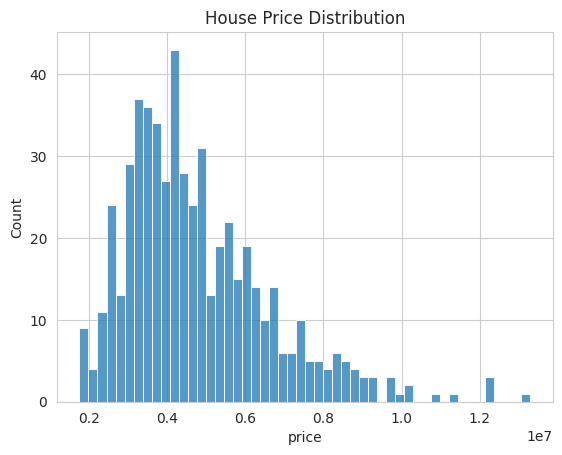

In [31]:
sns.histplot(df["price"], bins=50)
plt.title("House Price Distribution")
plt.show()

Correlation heatmap

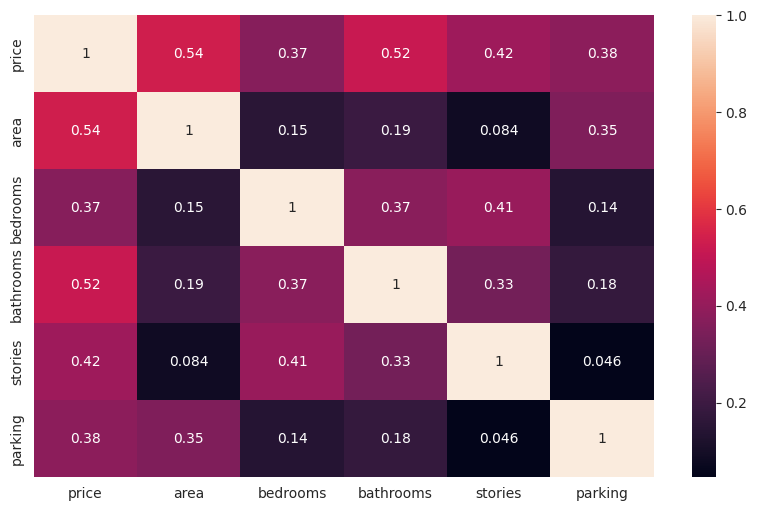

In [33]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

**Insight:**

sqft_living strongly correlates with price.

# **Feature Selection**

Select features

In [35]:
X = df[["bedrooms","bathrooms","area","stories"]]
y = df["price"]

# **Train-Test Split**

Split dataset

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Training data: 80%

Testing data: 20%

# **Train Machine Learning Model**

Use Linear Regression

In [37]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

# **Make Predictions**

In [38]:
y_pred = model.predict(X_test)

# **Evaluate Model**

Calculate performance metrics

In [39]:
mse = mean_squared_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 2457741642022.595
R2 Score: 0.5137585349036066


Interpretation:

| Metric | Meaning          |
| ------ | ---------------- |
| MSE    | prediction error |
| R²     | model accuracy   |


Higher R² means better prediction.

# **Save Model**

Save trained model

In [41]:
import joblib

joblib.dump(model, "model.pkl")

['model.pkl']

# **Build Prediction App**

Create app.py

In [ ]:
import streamlit as st
import joblib
import numpy as np

model = joblib.load("model.pkl")

st.title("House Price Prediction")

bedrooms = st.number_input("Bedrooms")
bathrooms = st.number_input("Bathrooms")
sqft_living = st.number_input("Living Area")
sqft_lot = st.number_input("Lot Size")
floors = st.number_input("Floors")

features = np.array([[bedrooms, bathrooms, sqft_living, sqft_lot, floors]])

prediction = model.predict(features)

if st.button("Predict"):
    st.write("Predicted House Price:", prediction[0])

# **Run Web Application**

Run Streamlit

In [ ]:
streamlit run app/app.py

Open browser

In [ ]:
localhost:8501

You now have a live **ML application**.

# **Final Project Outcome**

**Skills demonstrated:**

data preprocessing

exploratory data analysis

regression modeling

model evaluation

model deployment

This project shows recruiters you can build a real ML system from raw data to deployment.